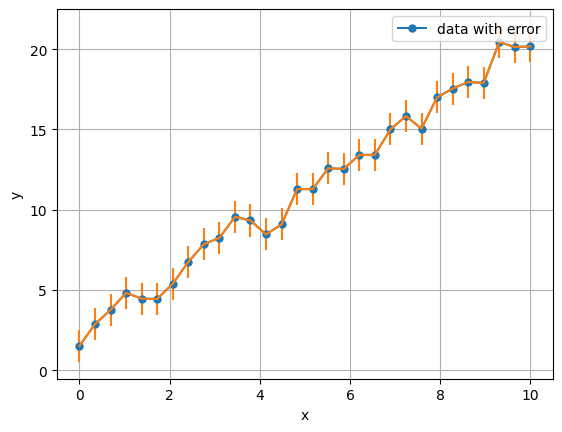

slope: 1.839410913512797
intercept: 2.075294232436016


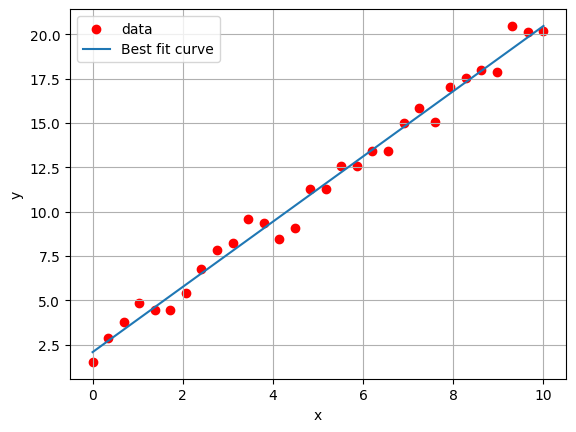

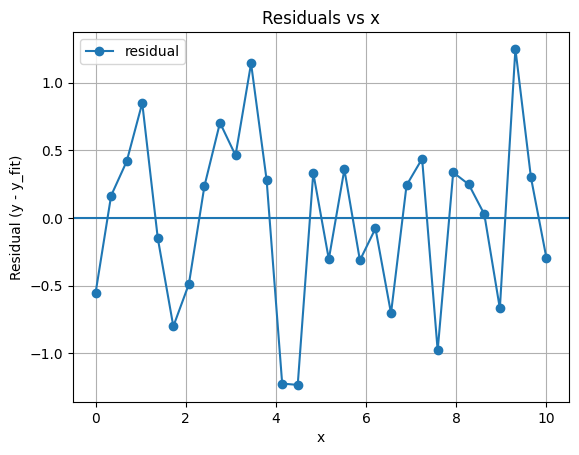

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#load and read the data
data = np.loadtxt('/content/drive/MyDrive/Colab Notebooks/Computational_Methods/Assignment-1(curve fit)/data_with_errors.txt')

#split the data into x, y, sigma
x = data[:, 0]
y = data[:, 1]
err = data[:, 2]

n = len(x)

#plot x vs y with error
plt.errorbar(x, y, marker='o', markersize=5, label='data with error')
plt.xlabel('x')
plt.ylabel('y')

plt.errorbar(x, y, yerr=err) #graph with error
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# plt.show()


w = 1 / err ** 2 #weights

sum_w   = np.sum(w)
sum_x  = np.sum(w * x)
sum_y  = np.sum(w * y)
sum_xx = np.sum(w * x**2)
sum_xy = np.sum(w * x * y)



# Least squares formulae
m = (sum_w * sum_xy - sum_x * sum_y) / (sum_w * sum_xx - sum_x**2)
c = (sum_xx * sum_y - sum_x * sum_xy) / (sum_w * sum_xx - sum_x**2)

print(f'slope: {m}')
print(f'intercept: {c}')


#best fit line
y_fit = m * x + c
plt.scatter(x, y, color='red', label='data')
plt.plot(x, y_fit, label='Best fit curve')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


#Calculate the residual and plot it vs ‘x’.

# Residuals
residual = y - y_fit

# Plot residuals vs x
plt.figure()
plt.plot(x, residual, marker='o', label='residual')
plt.axhline(0)   # reference line
plt.xlabel("x")
plt.ylabel("Residual (y - y_fit)")
plt.title("Residuals vs x")
plt.legend()
plt.grid(True)
plt.show()


#curve fitting(straight line) using scify

sigma = standard deviation (error / uncertainty) of each y data point




| Setting                | Meaning of `sigma`      | Are parameter errors physical? |
| ---------------------- | ----------------------- | ------------------------------ |
| `absolute_sigma=False` | relative weights        | ❌ No                           |
| `absolute_sigma=True`  | true measurement errors | ✅ Yes                          |


In [ ]:
#solving using scipy
from scipy.optimize import curve_fit


# Load data: x, y, sigma
x, y, error = np.loadtxt("data_with_errors.txt", unpack=True)  #unpack=True reads the data columnwise


# Model function
def linear_straight_line(x, a, b):
    return a + b*x

# Weighted fit (sigma = errors)
popt, pcov = curve_fit(linear_straight_line, x, y, sigma=error, absolute_sigma=True)
#popt = parameter optimal , it contains the best-fit values[slope(m) and intercept(c)] of the model parameters that minimize the least-squares error.
# popt[0] → optimal slope a
# popt[1] → optimal intercept b

#pcov = parameter covariance matrix, It tells us how uncertain our fitted parameters are and how they are correlated.
# pcov = | Var(a)     Cov(a,b) |
#        | Cov(b,a)  Var(b)   |
#Diagonal elements --→ parameter errors np.diag(pcov)-> [ Var(a), Var(b) ]
#sigma_a, sigma_b = np.sqrt(np.diag(pcov))
#σₐ → uncertainty in slope a
# σ_b → uncertainty in intercept b


a, b = popt
sigma_a, sigma_b = np.sqrt(np.diag(pcov))

print("a =", a)
print("b =", b)
print(f'error in slope: {sigma_a}')
print(f'error in intercept: {sigma_b}')


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#Define function
def straight_line(x, m, c):
    return  m * x + c

#Load data
x, y, err = np.loadtxt("data_with_errors.txt", unpack=True) #it read the data columnwise

popt, pcov = curve_fit(straight_line, x, y, sigma=err, absolute_sigma=True)
m, c = popt
sigma_m, sigma_c = np.sqrt(np.diag(pcov))
print(f'slope: {m}')
print(f'intercept: {c}')

plt.plot(x, straight_line(x, m, c), label='best fit line')
plt.errorbar(x, y, yerr=err, fmt='o',color='red', label='data with error')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

print(f'residuals: {residual}')

FileNotFoundError: data_with_errors.txt not found.